In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

## Count model

In [2]:
words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [3]:
# --- "training" the model ----

N = torch.zeros((27, 27), dtype=torch.int32)
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

In [4]:
# --- inference ---

P = N.float()
P /= P.sum(1, keepdims=True)

for i in range(3):  
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

ae.
kardore.
mon.


In [5]:
# --- train loss ---

log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

nll = -log_likelihood
avg_nll = (1/n)*nll
avg_nll.item()

2.454094171524048

## NN model

In [6]:
xs, ys = [], []

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
    
xs = torch.tensor(xs)
ys = torch.tensor(ys)

len(xs)

228146

In [7]:
# --- training ---
W = (torch.randn((27, 27)) * 0.001).requires_grad_()
optimizer = torch.optim.Adam([W], lr=0.1)

for k in range(2001):
    logits = W[xs]
    loss = F.cross_entropy(logits, ys)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if k % 500 == 0:
        print(k, loss.item())

0 3.2957913875579834
500 2.4541258811950684
1000 2.454052686691284
1500 2.4540340900421143
2000 2.454026460647583


In [8]:
with torch.no_grad():
    logits = W[xs]
    loss_all = F.cross_entropy(logits, ys)

loss_all.item(), -math.log(1/27)

(2.454026460647583, 3.295836866004329)

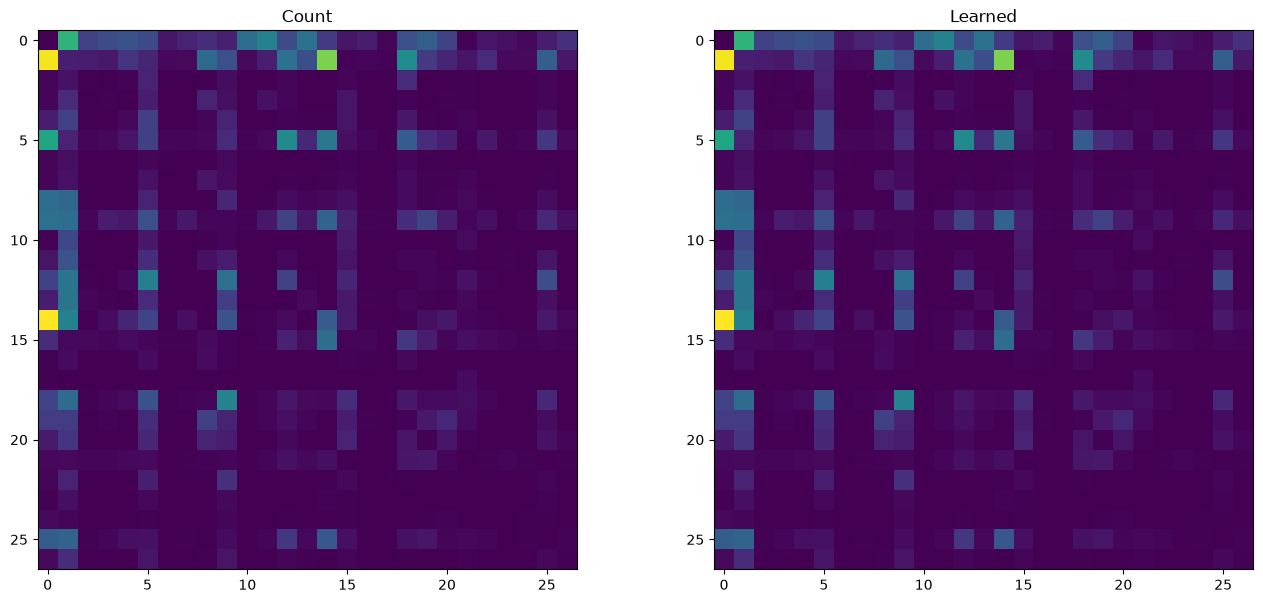

In [9]:
# Ei/sum(Ei) = Ni/sum(Ni) --> Ei = c * Ni --> Ei/c = Ni
# c = sum(Ei)/sum(Ni)
with torch.no_grad():
    E = W.exp()
    Nf = N.float()

    scale = E.sum(dim=1, keepdim=True) / Nf.sum(dim=1, keepdim=True)
    E_rescaled = E / scale

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

im0 = ax[0].imshow(Nf)
ax[0].set_title("Count");

im1 = ax[1].imshow(E_rescaled)
ax[1].set_title("Learned");

In [10]:
P_W = W.softmax(dim=1)
P_N = N.float() / N.sum(dim=1, keepdim=True)

(P_W - P_N).abs().max().item()

0.00033333897590637207

## More

Exercises:

- E01: train a trigram language model, i.e. take two characters as an input to predict the 3rd one. Feel free to use either counting or a neural net. Evaluate the loss; Did it improve over a bigram model?
- E02: split up the dataset randomly into 80% train set, 10% dev set, 10% test set. Train the bigram and trigram models only on the training set. Evaluate them on dev and test splits. What can you see?
- E03: use the dev set to tune the strength of smoothing (or regularization) for the trigram model - i.e. try many possibilities and see which one works best based on the dev set loss. What patterns can you see in the train and dev set loss as you tune this strength? Take the best setting of the smoothing and evaluate on the test set once and at the end. How good of a loss do you achieve?
- E04: we saw that our 1-hot vectors merely select a row of W, so producing these vectors explicitly feels wasteful. Can you delete our use of F.one_hot in favor of simply indexing into rows of W?
- E05: look up and use F.cross_entropy instead. You should achieve the same result. Can you think of why we'd prefer to use F.cross_entropy instead?
- E06: meta-exercise! Think of a fun/interesting exercise and complete it

## 3-gram

In [11]:
chars = sorted(list(set(''.join(words))))
chars.append('.')

ctxs = []
for c1 in chars:
    for c2 in chars:
        ctxs.append(c1+c2)

print(len(ctxs) - 27**2)

stoi = {i:c for c, i in enumerate(ctxs)}
itos = {v:k for k, v in stoi.items()}

stoi_y = {i:c for c, i in enumerate(chars)}
itos_y = {v:k for k, v in stoi_y.items()}

0


In [12]:
xs, ys = [], []

for w in words:
    chs = ['.', '.'] + list(w) + ['.']
    ctxs = [x1+x2 for x1, x2 in zip(chs, chs[1:-1])]
    for x, y in zip(ctxs, chs[2:]):
        xs.append(stoi[x])
        ys.append(stoi_y[y])
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)

xs.shape, ys.shape

(torch.Size([228146]), torch.Size([228146]))

In [13]:
W = (torch.randn((27*27, 27)) * 0.001)
print(W.shape)
print(xs.min().item())
print(xs.max().item())
W[7].shape
logits = W[xs]
print(logits.shape)
print(ys.shape)

torch.Size([729, 27])
0
728
torch.Size([228146, 27])
torch.Size([228146])


In [14]:
# --- training ---
W = (torch.randn((27*27, 27)) * 0.001).requires_grad_()
optimizer = torch.optim.Adam([W], lr=0.1)

for k in range(2001):
    logits = W[xs]
    loss = F.cross_entropy(logits, ys)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if k % 500 == 0:
        print(k, loss.item())

0 3.295839786529541
500 2.1862378120422363
1000 2.1859123706817627
1500 2.185828685760498
2000 2.1857943534851074


In [15]:
with torch.no_grad():
    logits = W[xs]
    loss = F.cross_entropy(logits, ys)
loss.item()

2.1857943534851074

## train-dev-test

In [16]:
chars = sorted(list(set(''.join(words))))
chars.append('.')

ctxs = []
for c1 in chars:
    for c2 in chars:
        ctxs.append(c1+c2)

assert len(ctxs) == 27**2

stoi = {i:c for c, i in enumerate(ctxs)}
itos = {v:k for k, v in stoi.items()}

stoi_y = {i:c for c, i in enumerate(chars)}
itos_y = {v:k for k, v in stoi_y.items()}

# --- create data set ---

xs, ys = [], []

for w in words:
    chs = ['.', '.'] + list(w) + ['.']
    ctxs = [x1+x2 for x1, x2 in zip(chs, chs[1:-1])]
    for x, y in zip(ctxs, chs[2:]):
        xs.append(stoi[x])
        ys.append(stoi_y[y])
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)

perm = torch.randperm(len(xs))
xs = xs[perm]
ys = ys[perm]

# 80 / 10 / 10 split
n = len(xs)
n1 = int(0.8 * n)
n2 = int(0.9 * n)

Xtr, Ytr = xs[:n1], ys[:n1]
Xdev, Ydev = xs[n1:n2], ys[n1:n2]
Xte, Yte = xs[n2:], ys[n2:]

print(len(Xtr), len(Xdev), len(Xte))

182516 22815 22815


In [17]:
regs = [0, 0.001, 0.01, 0.05, 0.1, 1]

for reg in regs:
    W = (torch.randn((27*27, 27)) * 0.001).requires_grad_()
    optimizer = torch.optim.Adam([W], lr=0.1)

    for _ in range(2000):
        logits = W[Xtr]
        loss = F.cross_entropy(logits, Ytr) + reg * (W**2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # some reg -> higher train loss, potentially lower dev loss
    with torch.no_grad():
        train_loss = F.cross_entropy(W[Xtr], Ytr).item()
        dev_loss   = F.cross_entropy(W[Xdev], Ydev).item()

    print(f"{reg=:<6} train={train_loss:.4f} dev={dev_loss:.4f}")

reg=0      train=2.1816 dev=2.2606
reg=0.001  train=2.1828 dev=2.2380
reg=0.01   train=2.1898 dev=2.2331
reg=0.05   train=2.2097 dev=2.2445
reg=0.1    train=2.2277 dev=2.2588
reg=1      train=2.3893 dev=2.4080


In [18]:
reg = 0.01

W = (torch.randn((27*27, 27)) * 0.001).requires_grad_()
optimizer = torch.optim.Adam([W], lr=0.1)

train_losses = []
dev_losses = []

for k in range(2000):
    # train
    logits = W[Xtr]
    loss = F.cross_entropy(logits, Ytr) + reg * (W**2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if k % 20 == 0:
        with torch.no_grad():
            train_loss = F.cross_entropy(W[Xtr], Ytr).item()
            dev_loss   = F.cross_entropy(W[Xdev], Ydev).item()

        train_losses.append(train_loss)
        dev_losses.append(dev_loss)

In [19]:
with torch.no_grad():
    test_loss = F.cross_entropy(W[Xte], Yte).item()

print(f"test loss: {test_loss:.4f}")

test loss: 2.2208


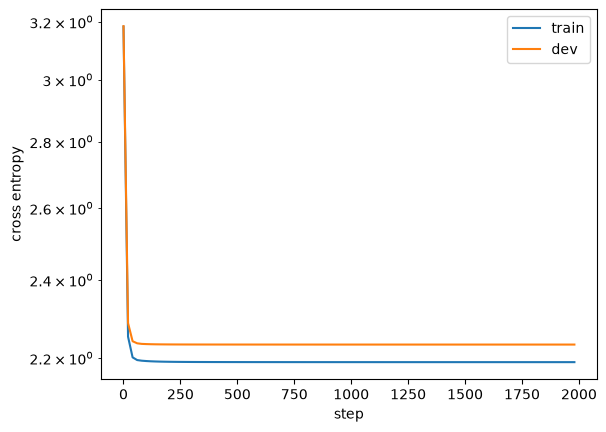

In [21]:
steps = range(0, 2000, 20)

plt.plot(steps, train_losses, label="train")
plt.plot(steps, dev_losses, label="dev")

plt.xlabel("step")
plt.ylabel("cross entropy")
plt.yscale("log")
plt.legend()
plt.show()